# ML Project Notebook

Rotem David Semah


In [85]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

TARGET_NAME = "Dropped_Course"

data = pd.read_csv("data/Train_Data.csv")
official_test_data = pd.read_csv("data/Test_Data_No_Target.csv")

### Helper functions


In [86]:
def plot_dropout_by_category(
    df: pd.DataFrame,
    col: str,
    target: str = TARGET_NAME,
    min_count: int = 50,
    top_n: int = 10,
    figsize=(9, 5),
):
    stats = df.groupby(col, dropna=False)[target].agg(dropout_rate="mean", count="size")

    stats = (
        stats[stats["count"] >= min_count]
        .sort_values("count", ascending=False)
        .head(top_n)
        .sort_values("dropout_rate", ascending=True)
    )

    labels = [f"{idx} (n={int(row['count'])})" for idx, row in stats.iterrows()]

    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(labels, stats["dropout_rate"] * 100)

    overall = df[target].mean() * 100
    ax.axvline(
        overall,
        linestyle="--",
        linewidth=1.5,
        label=f"Dataset mean ({overall:.1f}%)",
    )

    ax.set_xlabel("Dropout rate (%)")
    ax.set_title(f"Dropout rate by {col}")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return stats


def plot_dropout_by_numeric_bins(
    df: pd.DataFrame,
    col: str,
    target: str = TARGET_NAME,
    bins=8,
    figsize=(9, 4),
):
    tmp = df[[col, target]].dropna().copy()

    tmp["bin"] = pd.qcut(
        tmp[col],
        q=bins,
        duplicates="drop",
    )

    stats = tmp.groupby("bin", observed=True)[target].agg(
        dropout_rate="mean", count="size"
    )

    fig, ax = plt.subplots(figsize=figsize)

    stats["dropout_rate"].mul(100).plot.bar(ax=ax)

    overall = df[target].mean() * 100
    ax.axhline(
        overall,
        linestyle="--",
        linewidth=1.5,
        label=f"Dataset mean ({overall:.1f}%)",
    )

    ax.set_ylabel("Dropout rate (%)")
    ax.set_title(f"Dropout rate by {col} bins")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return stats


def plot_dropout_over_time(
    df: pd.DataFrame,
    date_col: str = "Course_Start_Date",
    target: str = TARGET_NAME,
    freq: str = "M",
    figsize=(12, 4),
):
    tmp = df[[date_col, target]].copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col], errors="coerce")
    tmp = tmp.dropna(subset=[date_col])

    stats = (
        tmp
        .groupby(tmp[date_col].dt.to_period(freq))[target]
        .agg(dropout_rate="mean", count="size")
        .sort_index()
    )

    fig, ax = plt.subplots(figsize=figsize)

    stats["dropout_rate"].mul(100).plot(
        ax=ax,
        marker="o",
    )

    overall = df[target].mean() * 100
    ax.axhline(
        overall,
        linestyle="--",
        linewidth=1.5,
        label=f"Dataset mean ({overall:.1f}%)",
    )

    ax.set_ylabel("Dropout rate (%)")
    ax.set_title("Dropout rate over time")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return stats


def br():
    print()

## 1. EDA


In [87]:
pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", None)
print("data shape: ", data.shape)
data.head()

data shape:  (63464, 29)


,Client_ID,Professionals_Count,Students_Count,Observers_Count,Course_Start_Date,Practical_Hours,Theory_Hours,Registration_Days_Before,Origin_Country,Catering_Package,Welcome_Gift_Type,Requested_Lab_Config,Assigned_Lab_Config,Prev_Course_Dropouts,Prev_Course_Attended,Pre_Course_Supports_Tickets,Physical_Course_Kits,Waiting_List_Days,Registration_Changes,Enrollment_Type,Lanyard_Color,Client_Category,Submission_Source,Returning_Client,Agent_ID,Company_ID,Payment_Terms,Daily_Tuition_Cost,Dropped_Course
0,13766,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,0,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
1,78660,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Blue,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
2,51396,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,USB Drive,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0
3,34000,2,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,0,General Admission,Red,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,101.5,0
4,69025,1,0.0,0,2015-07-01,0,2,257.0,PRT,Lunch Included,Branded Notebook,Standard PC (Windows),Standard PC (Windows),0,0,0,0.0,0,1,General Admission,Orange,Traditional IT & Telecomm,B2B Platforms & Resellers,0,219.0,NaN,Pay Upon Start,80.0,0


Split the labeled file into a development training set and a validation set. The separate `Test_Data_No_Target.csv` file is kept as the final prediction set.


In [88]:
train_data, valid_data = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data[TARGET_NAME],
)

print(f"train_data shape: {train_data.shape}")
print(f"valid_data shape: {valid_data.shape}")
train_data.info()

train_data shape: (50771, 29)
valid_data shape: (12693, 29)
<class 'pandas.core.frame.DataFrame'>
Index: 50771 entries, 8022 to 41357
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Client_ID                    50771 non-null  int64  
 1   Professionals_Count          50771 non-null  int64  
 2   Students_Count               50767 non-null  float64
 3   Observers_Count              50771 non-null  int64  
 4   Course_Start_Date            50771 non-null  object 
 5   Practical_Hours              50771 non-null  int64  
 6   Theory_Hours                 50771 non-null  int64  
 7   Registration_Days_Before     48645 non-null  float64
 8   Origin_Country               50333 non-null  object 
 9   Catering_Package             50434 non-null  object 
 10  Welcome_Gift_Type            50771 non-null  object 
 11  Requested_Lab_Config         49377 non-null  object 
 12  Assigned_Lab_Con

I use `df` as shorthand for the development training split during EDA. Target-based analysis is based on this labeled split. The official test file has no `Dropped_Course` label, so it is used only for schema and missingness checks.


In [89]:
df = train_data

### Dataset Scope And Target Balance

Before looking at individual features, I check the target distribution and compare missing-value patterns between the labeled data and the official test file.


In [90]:
target_balance = df[TARGET_NAME].value_counts().sort_index().to_frame("count")
target_balance["rate_%"] = (
    df[TARGET_NAME].value_counts(normalize=True).sort_index().mul(100).round(1)
)
display(target_balance)

missing_compare = pd.DataFrame({
    "train_missing_%": df.isna().mean().mul(100).round(2),
    "official_test_missing_%": official_test_data.isna().mean().mul(100).round(2),
    "train_missing_count": df.isna().sum(),
    "official_test_missing_count": official_test_data.isna().sum(),
})

missing_compare = missing_compare.query(
    "train_missing_count > 0 or official_test_missing_count > 0"
).sort_values("train_missing_%", ascending=False)

display(missing_compare)

,count,rate_%
Dropped_Course,,
0,29732,58.6
1,21039,41.4


,train_missing_%,official_test_missing_%,train_missing_count,official_test_missing_count
Company_ID,95.12,96.41,48295,15297.0
Agent_ID,17.58,17.61,8928,2794.0
Registration_Days_Before,4.19,4.05,2126,642.0
Requested_Lab_Config,2.75,3.01,1394,477.0
Physical_Course_Kits,1.61,1.43,819,227.0
Enrollment_Type,1.11,1.12,563,177.0
Submission_Source,0.93,0.94,474,149.0
Payment_Terms,0.91,0.91,463,144.0
Origin_Country,0.86,1.01,438,160.0
Catering_Package,0.66,0.70,337,111.0


The target is not severely imbalanced: roughly 59% of the training examples are not dropped and 41% are dropped. This supports using AUC as the main evaluation metric.

The official test file has similar missingness patterns to the labeled data. The missing-value strategy therefore needs to transform all rows consistently in both validation and final prediction data.


#### Missingness Versus Target

For columns with meaningful missingness, I also check whether the fact that a value is missing is itself related to dropout. This helps decide whether to add missingness indicators.


In [91]:
missingness_target_cols = [
    "Agent_ID",
    "Company_ID",
    "Registration_Days_Before",
    "Physical_Course_Kits",
    "Daily_Tuition_Cost",
    "Requested_Lab_Config",
    "Payment_Terms",
]

missingness_target_rows = []
for col in missingness_target_cols:
    stats = (
        df
        .assign(is_missing=df[col].isna())
        .groupby("is_missing")[TARGET_NAME]
        .agg(count="size", dropout_rate="mean")
        .reset_index()
    )
    stats["column"] = col
    missingness_target_rows.append(stats)

missingness_target_summary = pd.concat(missingness_target_rows, ignore_index=True)
missingness_target_summary["dropout_rate_%"] = (
    missingness_target_summary["dropout_rate"] * 100
).round(1)

missingness_target_summary[
    [
        "column",
        "is_missing",
        "count",
        "dropout_rate_%",
    ]
]

,column,is_missing,count,dropout_rate_%
0,Agent_ID,False,41843,43.1
1,Agent_ID,True,8928,33.8
2,Company_ID,False,2476,21.4
3,Company_ID,True,48295,42.5
4,Registration_Days_Before,False,48645,41.4
5,Registration_Days_Before,True,2126,41.9
6,Physical_Course_Kits,False,49952,41.5
7,Physical_Course_Kits,True,819,38.0
8,Daily_Tuition_Cost,False,50706,41.4
9,Daily_Tuition_Cost,True,65,52.3


Missingness is informative for some columns. Missing `Company_ID` is associated with a much higher dropout rate, which supports adding a company-presence indicator. Missing `Agent_ID` also has a different dropout profile. For `Registration_Days_Before` and `Physical_Course_Kits`, missingness itself is weaker, but missingness indicators are still useful because they distinguish observed values from imputed values.


### Checking Cat cols


First, inspect the non-numeric columns: missing values, cardinality, and the most frequent raw categories.


In [92]:
cat_cols = df.select_dtypes(include=["object"]).columns
print("Number of none numeric cols: ", len(cat_cols))
print("The % of none numeric cols: ", 100 * len(cat_cols) / (df.shape[1] - 1))


def get_cat_smr(df: pd.DataFrame, cat_cols: pd.DataFrame.columns):
    cat_rows = []
    for col in cat_cols:
        vc = (df[col].value_counts(dropna=False, normalize=True)).mul(100).round(1)
        top_8 = [f"{idx} ({pct:.1f}%)" for idx, pct in vc.head(8).items()]
        cat_rows.append({
            "column": col,
            "missing_%": round(df[col].isna().mean() * 100, 1),
            "missing_count": df[col].isna().sum(),
            "unique_count": df[col].nunique(dropna=True),
            "top_8_cat": top_8,
        })
    return pd.DataFrame(cat_rows).sort_values("missing_count", ascending=False)


get_cat_smr(df, cat_cols)

Number of none numeric cols:  11
The % of none numeric cols:  39.285714285714285


,column,missing_%,missing_count,unique_count,top_8_cat
4,Requested_Lab_Config,2.7,1394,8,"[Standard PC (Windows) (78.4%), Linux Workstation (13.2%), nan (2.7%), Dual Monitor Setup (2.1%), MacOS Station (1.6%), Laptop Docking Station (1.5%), High-GPU Unit (0.5%), Touch Screen Interface (0.0%)]"
6,Enrollment_Type,1.1,563,263,"[General Admission (63.8%), Affiliated Admission (21.4%), Contractual Agreement (3.2%), general admission (1.7%), GENERAL ADMISSION (1.6%), nan (1.1%), General Admission (0.8%), General Admission (0.8%)]"
9,Submission_Source,0.9,474,289,"[B2B Platforms & Resellers (76.8%), Direct Website Registration (7.3%), Dedicated Sales Team (4.0%), B2B PLATFORMS & RESELLERS (1.9%), b2b platforms & resellers (1.9%), nan (0.9%), B2B Platforms & Resellers (0.9%), B2B Platforms & Resellers (0.9%)]"
10,Payment_Terms,0.9,463,214,"[Pay Upon Start (73.1%), Prepaid (Non-Refundable) (15.2%), PAY UPON START (1.9%), pay upon start (1.8%), nan (0.9%), Pay Upon Start (0.9%), Pay Upon Start (0.8%), Pay Upon Start (0.8%)]"
1,Origin_Country,0.9,438,666,"[PRT (38.2%), FRA (10.1%), DEU (6.3%), ESP (5.7%), GBR (5.1%), ITA (3.9%), BRA (2.0%), BEL (2.0%)]"
2,Catering_Package,0.7,337,299,"[Standard (Coffee Only) (71.3%), No Food Plan (10.3%), Lunch Included (7.5%), standard (coffee only) (1.8%), STANDARD (COFFEE ONLY) (1.7%), Standard (Coffee Only) (0.8%), Standard (Coffee Only) (0.8%), Standard (Coffee Only) (0.8%)]"
0,Course_Start_Date,0.0,0,666,"[2015-10-16 (0.5%), 2016-11-07 (0.5%), 2015-09-18 (0.5%), 2016-10-13 (0.5%), 2015-08-14 (0.5%), 2016-06-17 (0.4%), 2016-06-24 (0.4%), 2016-06-15 (0.4%)]"
3,Welcome_Gift_Type,0.0,0,4,"[Branded Notebook (50.8%), Water Bottle (29.1%), USB Drive (15.9%), Portable Charger (4.1%)]"
5,Assigned_Lab_Config,0.0,0,9,"[Standard PC (Windows) (72.4%), Linux Workstation (18.4%), Laptop Docking Station (2.9%), MacOS Station (2.5%), Dual Monitor Setup (2.4%), High-GPU Unit (0.8%), Server Access Terminal (0.4%), Touch Screen Interface (0.2%)]"
7,Lanyard_Color,0.0,0,225,"[Blue (49.5%), Black (20.9%), Red (10.2%), Orange (5.2%), Green (3.9%), BLUE (1.2%), blue (1.2%), Blue (0.6%)]"


#### Categorical Data Quality

The raw categorical values contain artificial noise: casing differences, punctuation inside labels, spacing issues, and placeholder strings such as `unknown` or `?`. For example, a value like `blu#e` should map back to the same category as `blue`. I normalize these values before deeper categorical analysis.


In [93]:
import re

COMMON_NANS = {
    "nan",
    "none",
    "na",
    "n/a",
    "null",
    "",
    "unknown",
    "unknonwn",
    "?",
    "-",
    "--",
    ".",
}


def normalize_col(df: pd.DataFrame, col):
    s = df[col].astype("string")
    s = (
        s.str
        .strip()
        .str.lower()
        .str.replace(r"\band\b", "&", regex=True)
        .str.replace(r"[^a-z0-9&() ]+", "", regex=True)  # removes # ! * ? etc
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    s = s.mask(s.isin(COMMON_NANS), np.nan)
    df[col] = s


def normalize_cat_cols(df: pd.DataFrame, cat_cols):

    df = df.copy()

    for col in cat_cols:
        s = df[col].astype("string")

        s = (
            s.str
            .strip()
            .str.lower()
            .str.replace(r"\band\b", "&", regex=True)
            .str.replace(r"[^a-z0-9&() ]+", "", regex=True)  # removes # ! * ? etc
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

        s = s.mask(s.isin(COMMON_NANS), np.nan)

        df[col] = s

    return df


cat_normed_data = normalize_cat_cols(df, cat_cols)
get_cat_smr(cat_normed_data, cat_cols)

,column,missing_%,missing_count,unique_count,top_8_cat
4,Requested_Lab_Config,2.7,1394,8,"[standard pc (windows) (78.4%), linux workstation (13.2%), <NA> (2.7%), dual monitor setup (2.1%), macos station (1.6%), laptop docking station (1.5%), highgpu unit (0.5%), touch screen interface (0.0%)]"
9,Submission_Source,1.6,803,4,"[b2b platforms & resellers (85.5%), direct website registration (8.1%), dedicated sales team (4.5%), <NA> (1.6%), government procurement system (0.2%)]"
10,Payment_Terms,1.6,802,3,"[pay upon start (81.6%), prepaid (nonrefundable) (16.9%), <NA> (1.6%), refundable deposit (0.0%)]"
6,Enrollment_Type,1.1,563,4,"[general admission (71.1%), affiliated admission (23.8%), contractual agreement (3.6%), <NA> (1.1%), organizational arrangement (0.4%)]"
1,Origin_Country,0.9,438,148,"[prt (41.6%), fra (11.0%), deu (6.9%), esp (6.2%), gbr (5.5%), ita (4.3%), bra (2.2%), bel (2.1%)]"
2,Catering_Package,0.7,337,4,"[standard (coffee only) (79.4%), no food plan (11.6%), lunch included (8.3%), <NA> (0.7%), all inclusive (0.1%)]"
8,Client_Category,0.0,2,7,"[saas & software houses (46.0%), traditional it & telecomm (22.8%), big tech & multinationals (18.8%), fintech & banking (7.4%), industrial tech & iot (4.1%), nonprofit & edutech (0.7%), defense & govtech (0.2%), <NA> (0.0%)]"
0,Course_Start_Date,0.0,0,666,"[20151016 (0.5%), 20161107 (0.5%), 20150918 (0.5%), 20161013 (0.5%), 20150814 (0.5%), 20160617 (0.4%), 20160624 (0.4%), 20160615 (0.4%)]"
3,Welcome_Gift_Type,0.0,0,4,"[branded notebook (50.8%), water bottle (29.1%), usb drive (15.9%), portable charger (4.1%)]"
5,Assigned_Lab_Config,0.0,0,9,"[standard pc (windows) (72.4%), linux workstation (18.4%), laptop docking station (2.9%), macos station (2.5%), dual monitor setup (2.4%), highgpu unit (0.8%), server access terminal (0.4%), touch screen interface (0.2%)]"


After normalization, duplicate category variants collapse into cleaner groups.


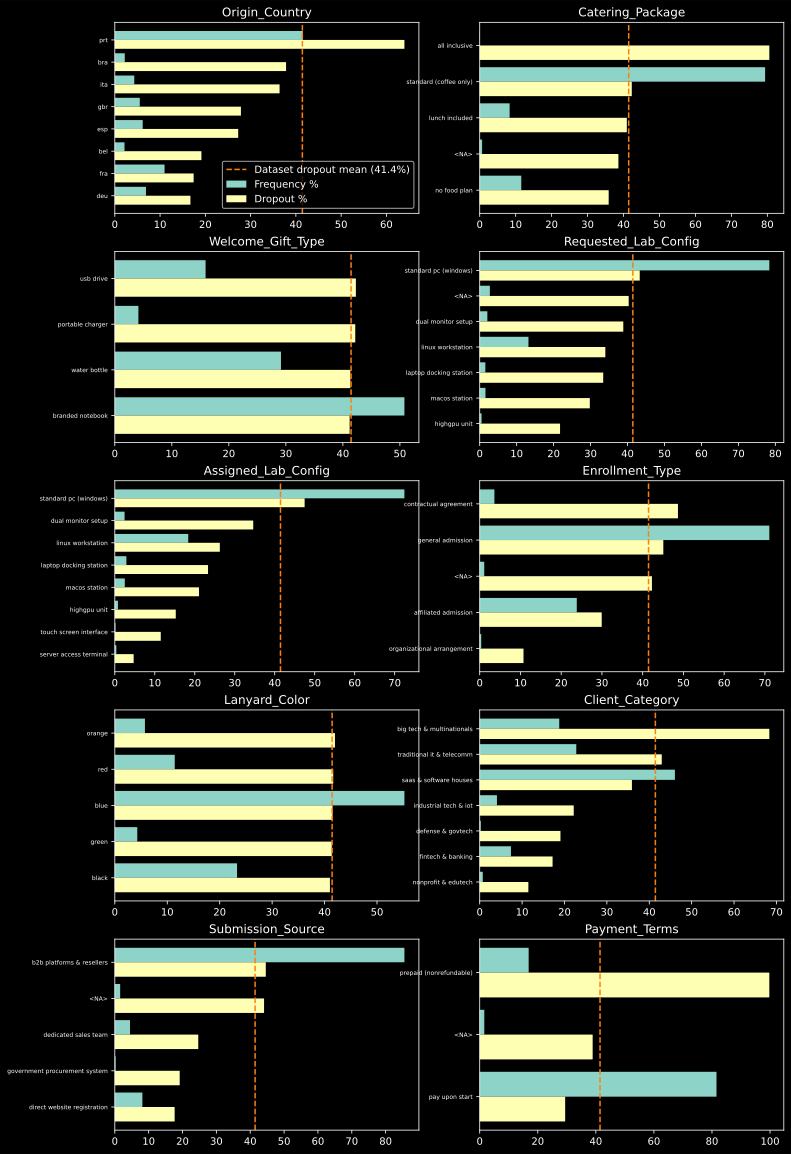

In [94]:
import math


normed_catted_df = normalize_cat_cols(df, cat_cols)

plot_cols = [c for c in cat_cols if c != "Course_Start_Date"]

ncols = 2
nrows = math.ceil(len(plot_cols) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 4 * nrows),
)

axes = axes.flatten()


def get_stats_for_top_freq_cats(
    df: pd.DataFrame,
    col: str,
    target: str = TARGET_NAME,
    min_count: int = 20,
    head: int = 8,
    sort_by: str = "dropout_rate",
    ascending: bool = False,
):
    """
    Select the top `head` categories by frequency, then sort that selected set for display.
    """
    stats = df.groupby(col, dropna=False)[target].agg(
        dropout_rate="mean",
        count="size",
    )

    stats = stats[stats["count"] >= min_count]
    stats = stats.sort_values("count", ascending=False).head(head)
    stats = stats.sort_values(sort_by, ascending=ascending)
    return stats


overall_dropout = normed_catted_df[TARGET_NAME].mean() * 100

for ax, col in zip(axes, plot_cols):
    stats = get_stats_for_top_freq_cats(
        normed_catted_df,
        col,
        ascending=True,
    )  # reverse sort for the plot
    frequency = stats["count"] / len(normed_catted_df) * 100
    dropout = stats["dropout_rate"] * 100

    y = np.arange(len(stats))
    h = 0.4

    ax.barh(
        y + h / 2,
        frequency,
        height=h,
        label="Frequency %",
    )

    ax.barh(
        y - h / 2,
        dropout,
        height=h,
        label="Dropout %",
    )

    ax.axvline(
        overall_dropout,
        linestyle="--",
        linewidth=1.5,
        color="tab:orange",
        label=f"Dataset dropout mean ({overall_dropout:.1f}%)",
    )

    ax.set_yticks(y)
    ax.set_yticklabels(stats.index, fontsize=6)
    ax.set_title(col)

    if ax is axes[0]:
        ax.legend()

Now I check whether the cleaned categorical values are actually related to dropout.


In [95]:
def show_cat_rate_table():
    cat_rate_rows = []

    for col in [
        col
        for col in cat_cols
        if col not in ["Lanyard_Color", "Welcome_Gift_Type", "Course_Start_Date"]
    ]:
        stats = get_stats_for_top_freq_cats(
            normed_catted_df,
            col,
            head=5,
            sort_by="count",
            ascending=False,
        )

        row = {"column": col}

        for i, (cat_value, cat_stats) in enumerate(stats.iterrows(), start=1):
            dropout_rate = cat_stats["dropout_rate"] * 100
            count = int(cat_stats["count"])

            row[f"top_{i}"] = f"{cat_value}: drop%={dropout_rate:.1f}, count={count}"

        cat_rate_rows.append(row)

    return pd.DataFrame(cat_rate_rows)


show_cat_rate_table()

,column,top_1,top_2,top_3,top_4,top_5
0,Origin_Country,"prt: drop%=64.0, count=21098","fra: drop%=17.4, count=5581","deu: drop%=16.7, count=3496","esp: drop%=27.3, count=3129","gbr: drop%=27.9, count=2803"
1,Catering_Package,"standard (coffee only): drop%=42.3, count=40305","no food plan: drop%=35.9, count=5868","lunch included: drop%=40.9, count=4225","<NA>: drop%=38.6, count=337","all inclusive: drop%=80.6, count=36"
2,Requested_Lab_Config,"standard pc (windows): drop%=43.3, count=39793","linux workstation: drop%=34.0, count=6698","<NA>: drop%=40.3, count=1394","dual monitor setup: drop%=38.9, count=1050","macos station: drop%=29.8, count=792"
3,Assigned_Lab_Config,"standard pc (windows): drop%=47.5, count=36779","linux workstation: drop%=26.3, count=9327","laptop docking station: drop%=23.3, count=1471","macos station: drop%=21.1, count=1268","dual monitor setup: drop%=34.6, count=1242"
4,Enrollment_Type,"general admission: drop%=45.1, count=36093","affiliated admission: drop%=29.9, count=12098","contractual agreement: drop%=48.7, count=1831","<NA>: drop%=42.3, count=563","organizational arrangement: drop%=10.8, count=186"
5,Client_Category,"saas & software houses: drop%=35.9, count=23378","traditional it & telecomm: drop%=42.9, count=11566","big tech & multinationals: drop%=68.3, count=9527","fintech & banking: drop%=17.2, count=3741","industrial tech & iot: drop%=22.2, count=2065"
6,Submission_Source,"b2b platforms & resellers: drop%=44.6, count=43432","direct website registration: drop%=17.7, count=4136","dedicated sales team: drop%=24.6, count=2280","<NA>: drop%=44.1, count=803","government procurement system: drop%=19.2, count=120"
7,Payment_Terms,"pay upon start: drop%=29.4, count=41404","prepaid (nonrefundable): drop%=99.8, count=8560","<NA>: drop%=38.9, count=802",NaN,NaN


The compact table above is a screening view: for each categorical feature it keeps the frequent categories and reports their dropout rate. This helps identify which categorical variables deserve cleaner final plots. `Lanyard_Color` and `Welcome_Gift_Type` show weak business patterns, while `Payment_Terms`, `Client_Category`, `Submission_Source`, `Enrollment_Type`, and `Agent_ID` show meaningful differences.


**Payment terms signal**

`Payment_Terms` is a very strong categorical signal: prepaid nonrefundable registrations have an unusually high dropout rate compared with pay-upon-start registrations. This feature should be retained and checked again during model evaluation because it may dominate the model.


In [96]:
normed_catted_df.groupby("Payment_Terms")["Dropped_Course"].agg(
    count="size",
    mean="mean",
)

,count,mean
Payment_Terms,,
pay upon start,41404,0.294295
prepaid (nonrefundable),8560,0.997547
refundable deposit,5,0.600000


**Course start date pattern**


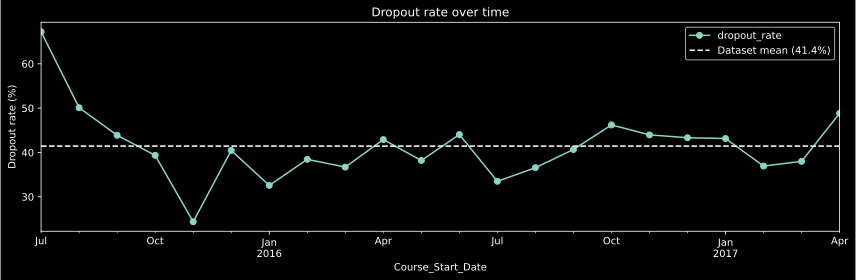

,dropout_rate,count
Course_Start_Date,,
2015-07,0.672337,1117
2015-08,0.501007,1986
2015-09,0.438793,2851
2015-10,0.393498,2676
2015-11,0.243680,989
2015-12,0.404655,1332
2016-01,0.325709,1093
2016-02,0.384575,1906
2016-03,0.366999,2406


In [97]:
plot_dropout_over_time(df)

#### Categorical Conclusions

The categorical EDA reveals both data-quality issues and predictive patterns. Category normalization is therefore part of data cleaning, and the same normalization should be reused later for validation and final prediction data.

Key conclusions:

- `Payment_Terms` is the strongest categorical signal.
- `Client_Category`, `Submission_Source`, and `Enrollment_Type` show meaningful differences in dropout rates and should be encoded.
- `Lanyard_Color` and `Welcome_Gift_Type` are candidates for removal because they do not show a useful relationship with dropout.
- `Course_Start_Date` shows a clear time pattern. It should be represented through date-derived features or careful categorical handling.
- Categorical missing values should be encoded explicitly as a `missing` category.


### Numeric cols


First, we have to separate numeric features into three subsets:

- the target
- true numeric features
- identifier numbers, such as client ID or agent ID, etc., which shouldn't really be treated as a number.


In [98]:
all_num_cols = df.select_dtypes(include=["int64", "float64"]).columns
IDE_COLNAMES = ["Agent_ID", "Company_ID", "Client_ID"]
TARGET = "Dropped_Course"
ide_cols = [col for col in all_num_cols if col in IDE_COLNAMES]

num_cols = [col for col in all_num_cols if col not in IDE_COLNAMES and col != TARGET]

#### Identifier columns


Analyze `Agent_ID` and `Company_ID` as categorical identifiers.


In [99]:
get_cat_smr(df, ide_cols)

,column,missing_%,missing_count,unique_count,top_8_cat
2,Company_ID,95.1,48295,169,"[nan (95.1%), 5181.0 (1.2%), 5013.0 (0.4%), 5194.0 (0.3%), 5119.0 (0.2%), 5024.0 (0.2%), 5185.0 (0.2%), 5025.0 (0.2%)]"
1,Agent_ID,17.6,8928,196,"[184.0 (34.8%), nan (17.6%), 218.0 (10.4%), 104.0 (4.1%), 264.0 (3.7%), 219.0 (3.1%), 224.0 (2.0%), 205.0 (1.7%)]"
0,Client_ID,0.0,0,50771,"[72948 (0.0%), 17739 (0.0%), 32579 (0.0%), 46415 (0.0%), 12303 (0.0%), 19224 (0.0%), 73044 (0.0%), 45587 (0.0%)]"


In [100]:
df["Client_ID"].nunique() == len(df)

True

`Client_ID` is unique per row, so it is not useful as a predictive feature. `Agent_ID` and `Company_ID` are numeric identifiers, but their values represent categories rather than quantities, so they are analyzed as categorical variables.

`Company_ID` is missing for most rows. That missingness is meaningful because it separates registrations made through a company from registrations without a company identifier.


In [101]:
ide_cols = [col for col in ide_cols if col != "Client_ID"]

In [102]:
def plot_id_target_rate(
    df: pd.DataFrame,
    col: str,
    target: str = TARGET_NAME,
    min_count: int = 100,
    top_n: int = 15,
    figsize=(10, 8),
):
    return plot_dropout_by_category(
        df,
        col,
        target=target,
        min_count=min_count,
        top_n=top_n,
        figsize=figsize,
    )

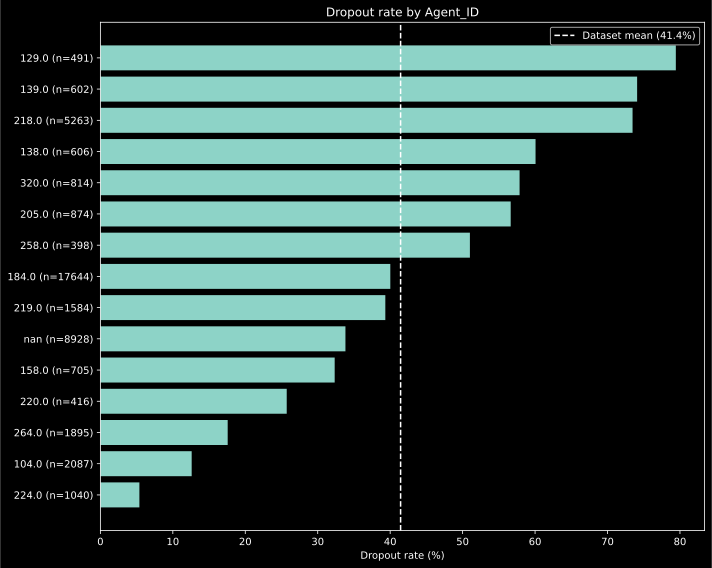

,dropout_rate,count
Agent_ID,,
224.0,0.053846,1040
104.0,0.126018,2087
264.0,0.175726,1895
220.0,0.257212,416
158.0,0.323404,705
NaN,0.338262,8928
219.0,0.393308,1584
184.0,0.400193,17644
258.0,0.510050,398


In [103]:
plot_id_target_rate(df, "Agent_ID")

**Agent ID signal**

Dropout rates differ substantially between frequent agents. This indicates that `Agent_ID` contains useful categorical information.


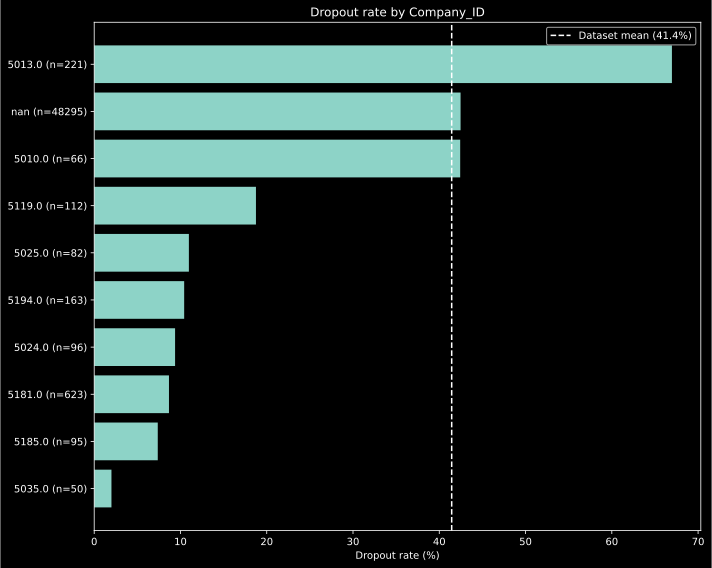

,dropout_rate,count
Company_ID,,
5035.0,0.020000,50
5185.0,0.073684,95
5181.0,0.086677,623
5024.0,0.093750,96
5194.0,0.104294,163
5025.0,0.109756,82
5119.0,0.187500,112
5010.0,0.424242,66
NaN,0.424682,48295


In [104]:
plot_id_target_rate(
    df,
    "Company_ID",
    min_count=50,
    top_n=10,
)

Registrations with a company identifier have substantially lower dropout than registrations without one. This supports creating a `has_company_id` feature and treating `Company_ID` as a categorical feature only when enough observations are available.


In [105]:
df.groupby(df.Company_ID.notna()).Dropped_Course.agg(count="size", drop_rate="mean")

,count,drop_rate
Company_ID,,
False,48295,0.424682
True,2476,0.213651


The company-presence comparison confirms that the registration path is meaningful: rows with a company identifier have lower dropout than rows without one.


#### Numeric Columns


In [106]:
CALC_PLOTS = False


def plot_numeric_dist(df, col, target=TARGET_NAME):
    if col == target:
        return

    s = df[col]

    print(f"{col}")
    print(f"missing: {s.isna().sum()} ({s.isna().mean() * 100:.2f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    sns.boxplot(data=df, x=target, y=col, ax=axes[0])
    axes[0].set_title("By target")

    sns.histplot(data=df, x=col, hue=target, bins=50, ax=axes[1])
    axes[1].set_title("Distribution")

    plt.tight_layout()
    plt.show()


if CALC_PLOTS:
    for col in num_cols:
        plot_numeric_dist(df, col)

In [107]:
def get_num_smr(
    df: pd.DataFrame,
    cols,
    target="Dropped_Course",
):
    rows = []

    for col in cols:
        s = df[col]

        rows.append({
            "column": col,
            "missing_%": round(s.isna().mean() * 100, 1),
            "missing_count": s.isna().sum(),
            "corr_target": round(
                s.corr(df[target]),
                3,
            ),
            "mean": round(s.mean(), 2),
            "median": round(s.median(), 2),
            "std": round(s.std(), 2),
            "min": round(s.min(), 2),
            "max": round(s.max(), 2),
            "q25": round(s.quantile(0.25), 2),
            "q75": round(s.quantile(0.75), 2),
            "skew": round(s.skew(), 2),
        })

    return pd.DataFrame(rows).sort_values(
        "corr_target",
        key=abs,
        ascending=False,
    )


get_num_smr(df, num_cols)

,column,missing_%,missing_count,corr_target,mean,median,std,min,max,q25,q75,skew
5,Registration_Days_Before,4.2,2126,0.351,103.20,65.0,109.55,0.0,629.0,19.0,150.0,1.50
8,Pre_Course_Supports_Tickets,0.0,0,-0.300,0.51,0.0,0.76,0.0,5.0,0.0,1.0,1.47
6,Prev_Course_Dropouts,0.0,0,0.204,0.10,0.0,0.44,0.0,21.0,0.0,0.0,15.55
11,Registration_Changes,0.0,0,-0.147,0.18,0.0,0.59,0.0,21.0,0.0,0.0,6.90
9,Physical_Course_Kits,1.6,819,-0.138,0.03,0.0,0.16,0.0,3.0,0.0,0.0,5.99
10,Waiting_List_Days,0.0,0,0.068,4.00,0.0,23.21,0.0,391.0,0.0,0.0,9.24
12,Returning_Client,0.0,0,-0.059,0.03,0.0,0.16,0.0,1.0,0.0,0.0,5.87
0,Professionals_Count,0.0,0,0.056,1.83,2.0,0.51,0.0,4.0,2.0,2.0,-0.47
7,Prev_Course_Attended,0.0,0,-0.050,0.12,0.0,1.55,0.0,61.0,0.0,0.0,22.04
4,Theory_Hours,0.0,0,0.044,2.17,2.0,1.47,0.0,41.0,1.0,3.0,3.38


**Numeric missing values**

The numeric summary table gives the first pass: missingness, correlation with the target, central tendency, spread, and extreme values.

Missing-value decisions:

- Most numeric columns: use median imputation fitted on the development training split. This is stable and easy to justify.
- Important missing columns: add missingness indicators, because missingness itself is informative for several features.
- `Daily_Tuition_Cost`: use median imputation and keep a missingness indicator. The missing rate is very low, so this is simpler and easier to reuse safely than a separate model-based imputer.
- Categorical columns: fill missing values with an explicit `missing` category after normalization.

The CRISP-DM lecture emphasizes sklearn preprocessing tools. I therefore fit the imputers on the development training split and reuse the fitted objects for validation and final prediction data.


In [108]:
sus_cols = [
    "Waiting_List_Days",
    "Prev_Course_Attended",
    "Registration_Days_Before",
    "Practical_Hours",
    "Students_Count",
    "Daily_Tuition_Cost",
]
for col in sus_cols:
    print(col)
    print(", ".join(map(str, df[col].nlargest(20).unique())))
    br()

Waiting_List_Days
391

Prev_Course_Attended
61, 60, 59, 58, 57, 56, 55, 54, 49, 48, 47, 46, 45, 44, 43, 42, 41

Registration_Days_Before
629.0, 626.0

Practical_Hours
10000, 5000

Students_Count
9999.0

Daily_Tuition_Cost
5400.0, 451.5, 375.5, 365.0, 349.63, 345.0, 332.57, 316.0, 314.1, 312.5, 309.5, 306.0, 300.0, 299.33, 295.0, 294.35



`Prev_Course_Attended` has high values, but they form a smooth tail and remain plausible for recurring organizations. `Daily_Tuition_Cost = 5400` is a suspicious high value and should be revisited in the outlier-analysis section. `Students_Count = 9999` and extreme `Practical_Hours` values look like placeholder or entry errors.


In [109]:
sus_cols = [
    col for col in sus_cols if col not in ["Prev_Course_Attended", "Daily_Tuition_Cost"]
]
for col in sus_cols:
    print(f"\n{col}")
    print(df[col].quantile([0.9999, 0.999, 0.995, 0.99, 0.95, 0.9]))
    br()


Waiting_List_Days
0.9999    391.0
0.9990    330.0
0.9950    176.0
0.9900    100.3
0.9500     17.0
0.9000      0.0
Name: Waiting_List_Days, dtype: float64


Registration_Days_Before
0.9999    629.0
0.9990    622.0
0.9950    531.0
0.9900    447.0
0.9500    326.0
0.9000    277.0
Name: Registration_Days_Before, dtype: float64


Practical_Hours
0.9999    10000.00
0.9990        8.23
0.9950        4.00
0.9900        3.00
0.9500        2.00
0.9000        2.00
Name: Practical_Hours, dtype: float64


Students_Count
0.9999    9999.0
0.9990       3.0
0.9950       2.0
0.9900       2.0
0.9500       1.0
0.9000       0.0
Name: Students_Count, dtype: float64



**Outlier candidates**

The clearest invalid or suspicious values are:

- `Students_Count`: values above the 99.9th percentile jump from normal small counts to `9999`.
- `Practical_Hours`: negative values and very large values such as `5000`/`10000` are not plausible course-hour values.

`Waiting_List_Days` and `Registration_Days_Before` have long tails, but those values can represent real early registrations or long waiting periods, so they are retained at this stage.


In [110]:
def make_capped_copy(df: pd.DataFrame, cols: list[str], q: float = 0.999):
    capped_df = df.copy()
    cap_rows = []

    for col in cols:
        cap = capped_df[col].quantile(q)
        n_capped = (capped_df[col] > cap).sum()
        cap_rows.append({"column": col, "cap": cap, "values_set_missing": n_capped})
        capped_df[col] = capped_df[col].where(
            capped_df[col] <= cap,
            pd.NA,
        )

    return capped_df, pd.DataFrame(cap_rows)


df_capped, cap_summary = make_capped_copy(df, ["Students_Count", "Practical_Hours"])
display(cap_summary)

,column,cap,values_set_missing
0,Students_Count,3.00,43
1,Practical_Hours,8.23,51


<Axes: >

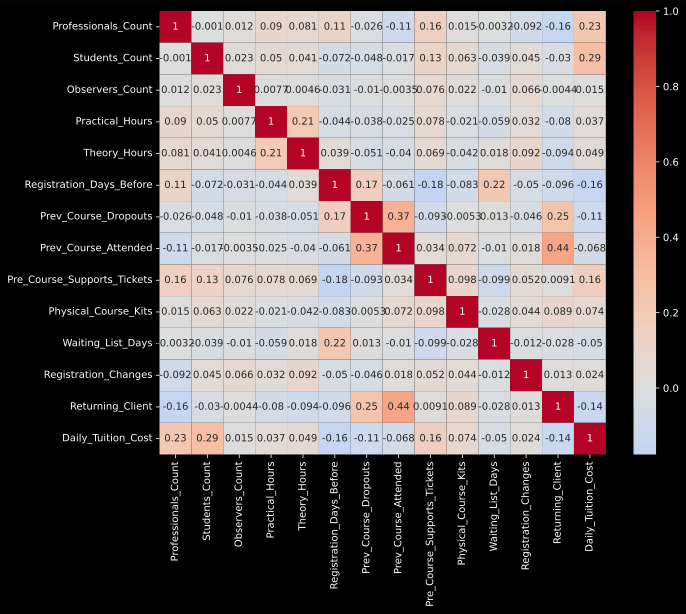

In [111]:
corr_matrix = df_capped[num_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)

In [112]:
CORR_THRESH = 0.2

corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1,
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature_1",
    "feature_2",
    "corr",
]

corr_pairs = corr_pairs[corr_pairs["corr"].abs() >= CORR_THRESH].sort_values(
    "corr",
    key=abs,
    ascending=False,
)
corr_pairs

,feature_1,feature_2,corr
74,Prev_Course_Attended,Returning_Client,0.443719
63,Prev_Course_Dropouts,Prev_Course_Attended,0.367656
24,Students_Count,Daily_Tuition_Cost,0.294568
68,Prev_Course_Dropouts,Returning_Client,0.245439
12,Professionals_Count,Daily_Tuition_Cost,0.226151
59,Registration_Days_Before,Waiting_List_Days,0.221273
36,Practical_Hours,Theory_Hours,0.207055


### Final EDA Plots

These are the curated EDA plots kept for the report. Earlier tables are used for screening; these plots communicate the main conclusions more clearly.


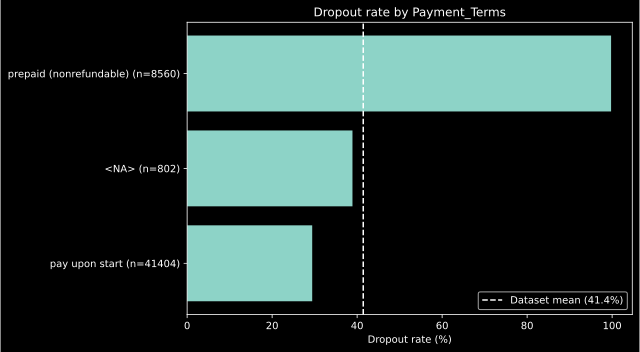

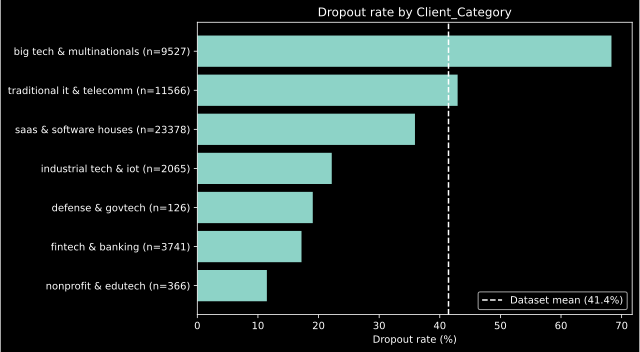

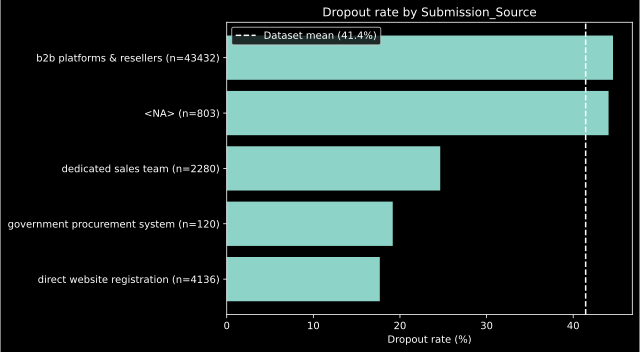

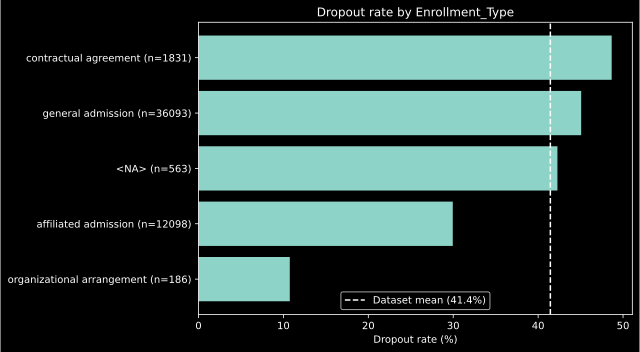

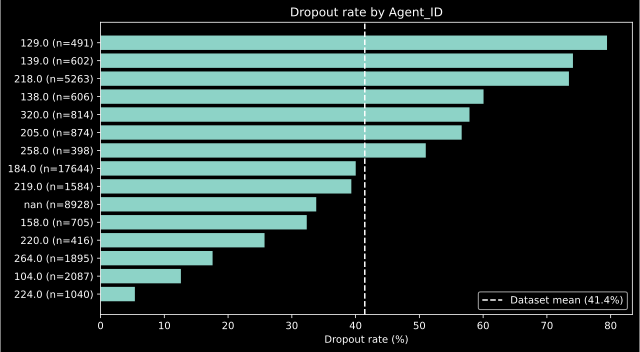

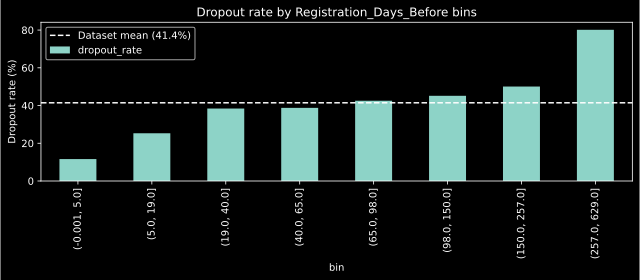

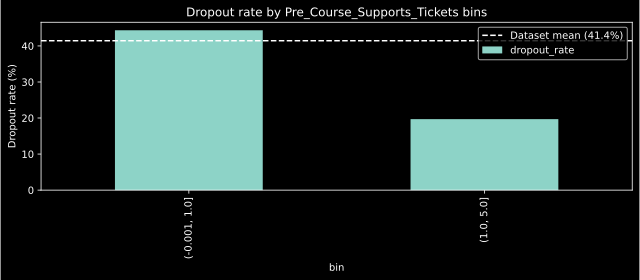

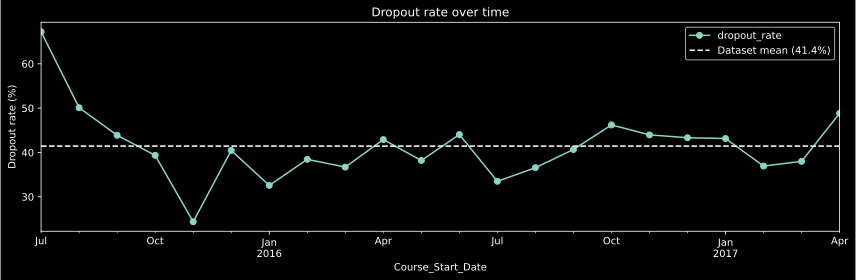

In [113]:
payment_terms_stats = plot_dropout_by_category(
    normed_catted_df, "Payment_Terms", min_count=20, top_n=5
)
client_category_stats = plot_dropout_by_category(
    normed_catted_df, "Client_Category", min_count=100, top_n=8
)
submission_source_stats = plot_dropout_by_category(
    normed_catted_df, "Submission_Source", min_count=100, top_n=6
)
enrollment_type_stats = plot_dropout_by_category(
    normed_catted_df, "Enrollment_Type", min_count=100, top_n=6
)
agent_stats = plot_dropout_by_category(df, "Agent_ID", min_count=100, top_n=15)
registration_days_stats = plot_dropout_by_numeric_bins(
    df_capped, "Registration_Days_Before", bins=8
)
support_tickets_stats = plot_dropout_by_numeric_bins(
    df_capped, "Pre_Course_Supports_Tickets", bins=6
)
course_start_stats = plot_dropout_over_time(df)

#### Final Plot Interpretation

- `Payment_Terms`: prepaid nonrefundable registrations have a much higher dropout rate than pay-upon-start registrations, making this one of the strongest categorical signals.
- `Client_Category`: dropout differs strongly by segment. Big tech and multinational clients are above the dataset mean, while nonprofit/edtech, fintech/banking, and industrial tech/IoT are lower.
- `Submission_Source`: direct website and dedicated-sales registrations are lower risk than B2B platform/reseller traffic.
- `Enrollment_Type`: organizational arrangements and affiliated admissions are lower risk than general admission and contractual agreement.
- `Agent_ID`: frequent agents have very different dropout rates, so the agent identifier carries useful categorical information.
- `Registration_Days_Before`: dropout rises as registration happens further before the course, especially in the highest bin.
- `Pre_Course_Supports_Tickets`: rows with more support tickets have lower dropout in this data, suggesting that pre-course engagement may be protective.
- `Course_Start_Date`: dropout changes over time, suggesting a period or seasonality effect.

Overall EDA conclusion: the strongest visible signals are payment terms, registration timing, agent/company registration path, client segment, source/enrollment channel, and support-ticket engagement.


### Missing Value Completion

The missing-value completion step follows the EDA conclusions. Numeric columns are filled with train-fitted medians, categorical columns receive an explicit `missing` category, and important missing columns receive missingness indicators. I use a simple median rule for `Daily_Tuition_Cost` as well: the missing rate is very low, and the median rule keeps the preprocessing easy to explain and reuse safely for validation and final prediction data.


In [114]:
ID_CATEGORICAL_COLS = ["Agent_ID", "Company_ID"]
IMPORTANT_MISSING_FLAGS = [
    "Agent_ID",
    "Registration_Days_Before",
    "Physical_Course_Kits",
    "Daily_Tuition_Cost",
    "Requested_Lab_Config",
    "Payment_Terms",
]


def complete_missing_values(
    data: pd.DataFrame,
    train_df: pd.DataFrame = df,
) -> pd.DataFrame:
    df = data.copy()

    num_cols = [
        col
        for col in train_df.select_dtypes(include=["int64", "float64"]).columns
        if col not in {TARGET_NAME, "Client_ID", *ID_CATEGORICAL_COLS}
    ]

    cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
    num_medians = train_df[num_cols].median()

    if "Client_ID" in df.columns:
        df = df.drop(columns=["Client_ID"])

    if "Company_ID" in df.columns:
        df["has_company_id"] = df["Company_ID"].notna().astype(int)

    for col in IMPORTANT_MISSING_FLAGS:
        if col in df.columns:
            df[f"{col}_missing"] = df[col].isna().astype(int)

    present_numeric_cols = [col for col in num_cols if col in df.columns]
    df[present_numeric_cols] = df[present_numeric_cols].fillna(
        num_medians[present_numeric_cols]
    )

    present_categorical_cols = [col for col in cat_cols if col in df.columns]

    df = normalize_cat_cols(df, present_categorical_cols)

    df[present_categorical_cols] = (
        df[present_categorical_cols].fillna("missing").astype("object")
    )

    for col in ID_CATEGORICAL_COLS:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype("string")
                .str.replace(r"\.0$", "", regex=True)
                .fillna("missing")
                .astype("object")
            )

    return df

## 2. Outlier Analysis & Feature Engineering


### Baseline Model Benchmark

The benchmark separates feature engineering from generic preprocessing. Each
`prepare_features_*` function creates a concrete modeling table. The benchmark then
handles only generic steps: missing-value imputation, categorical encoding, numeric
scaling, and model fitting. This makes the experiment readable: every added feature
group can be compared with the same benchmark.


Utils:


In [115]:
DF = pd.DataFrame  # a shorter alias for typechecking

train_df = complete_missing_values(train_data, train_data)
val_df = complete_missing_values(valid_data, train_data)

test_df = complete_missing_values(
    pd.read_csv("data/Test_Data_No_Target.csv"), train_data
)


def split_xy(df: DF, target=TARGET_NAME):
    X, y = df.drop(columns=[target]), df[target]
    return X, y


def get_train_val_xy(train_df: DF, val_df: DF):
    X_train, y_train = split_xy(train_df)
    X_val, y_val = split_xy(val_df)
    return X_train, y_train, X_val, y_val


def encode_cats(X_train, X_val):
    cat_cols = X_train.select_dtypes(include=["object", "string"]).columns

    enc = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
        feature_name_combiner=lambda col, val: f"ohe__{col}__{val}",
    ).set_output(transform="pandas")

    return (
        pd.concat(
            [
                X_train.drop(columns=cat_cols),
                enc.fit_transform(X_train[cat_cols]),
            ],
            axis=1,
        ),
        pd.concat(
            [
                X_val.drop(columns=cat_cols),
                enc.transform(X_val[cat_cols]),
            ],
            axis=1,
        ),
    )

**Scorring for 3 models**


In [116]:
from sklearn.preprocessing import StandardScaler


def get_lg_model():
    return LogisticRegression(
        max_iter=2000,
    )


def get_rf_model():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1,
    )


def get_xgb_model():
    return XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )


def get_score(train_df, val_df, model, scale=False):
    X_train, y_train, X_val, y_val = get_train_val_xy(train_df, val_df)
    X_train, X_val = encode_cats(X_train, X_val)

    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

    model.fit(X_train, y_train)
    preds = model.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, preds)


MODELS = {
    "Logistic Regression": {
        "model_getter": get_lg_model,
        "scale": True,
    },
    "Random Forest": {
        "model_getter": get_rf_model,
        "scale": False,
    },
    "XGBoost": {
        "model_getter": get_xgb_model,
        "scale": False,
    },
}


def benchmark_models(train_df, val_df):
    rows = []

    for name, cfg in MODELS.items():
        score = get_score(
            train_df,
            val_df,
            model=cfg["model_getter"](),
            scale=cfg["scale"],
        )

        rows.append({
            "model": name,
            "auc": score,
        })

    return pd.DataFrame(rows).sort_values("auc", ascending=False)


scores_0 = benchmark_models(train_df, val_df)
display(scores_0)

,model,auc
2,XGBoost,0.943122
1,Random Forest,0.923396
0,Logistic Regression,0.915387


#### Conclusions

All 3 models are doing surprinsgly well. I want to see what happens if i drop the start_date


**Concerns about `Course_Start_Date`**

Course start date has a few problems. One is simply that we have too many categories, which bloats the dimensions. The second, and more concerning, issue is that the test data includes dates that are not present in the training set. The model might find correlations between specific dates and drop rates, but those correlations could relate to events outside the data—such as an economic crisis. Many factors could impact the results over time, so we shouldn’t expect the old dates to predict the new ones. Let’s see how much it matters and whether it’s safe to drop it.


In [117]:
train_no_date = train_df.drop(columns=["Course_Start_Date"])
val_no_date = val_df.drop(columns=["Course_Start_Date"])

scores_1 = benchmark_models(train_no_date, val_no_date)

score_compare = scores_0.merge(
    scores_1,
    on="model",
    suffixes=("_with_date", "_no_date"),
)

score_compare["diff"] = score_compare["auc_with_date"] - score_compare["auc_no_date"]
score_compare = score_compare.sort_values("diff", ascending=False)

display(score_compare)

,model,auc_with_date,auc_no_date,diff
2,Logistic Regression,0.915387,0.912068,0.003319
0,XGBoost,0.943122,0.943394,-0.000272
1,Random Forest,0.923396,0.927486,-0.004090


**Im dropping it.**


AUC: 0.9233962690273925


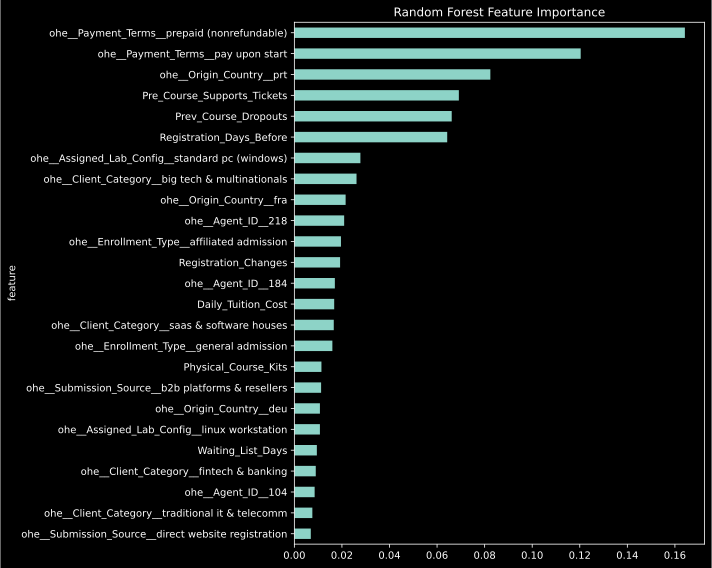

,feature,importance
1255,ohe__Payment_Terms__prepaid (nonrefundable),0.164193
1254,ohe__Payment_Terms__pay upon start,0.120388
802,ohe__Origin_Country__prt,0.082403
8,Pre_Course_Supports_Tickets,0.069162
6,Prev_Course_Dropouts,0.066158
5,Registration_Days_Before,0.064263
860,ohe__Assigned_Lab_Config__standard pc (windows),0.027766
873,ohe__Client_Category__big tech & multinationals,0.026138
733,ohe__Origin_Country__fra,0.021555
987,ohe__Agent_ID__218,0.020938


In [122]:
def get_encoded_xy(train_df, val_df):
    X_train, y_train, X_val, y_val = get_train_val_xy(train_df, val_df)
    X_train, X_val = encode_cats(X_train, X_val)
    return X_train, y_train, X_val, y_val


X_train, y_train, X_val, y_val = get_encoded_xy(train_df, val_df)

rf = get_rf_model()

rf.fit(X_train, y_train)

preds = rf.predict_proba(X_val)[:, 1]
print("AUC:", roc_auc_score(y_val, preds))
rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)


rf_importance.head(30)
rf_importance.head(25).sort_values("importance").plot.barh(
    x="feature",
    y="importance",
    figsize=(10, 8),
    legend=False,
)


plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
display(rf_importance.head(70))

The results are concerning because the strongest feature here is clearly the suspicious one: non‑refundable payment. It seems either to be an error or something they flipped, but it just doesn’t make sense that there would be an almost 100 % correlation between that and the dropout rate. It just doesn’t make sense, and that is concerning. What happens if we drop that from the model? How badly will it perform afterward? The question is whether we can trust the same corruption or weird coincidence to also apply in the test data. I’m not sure. So it’s a big question what we do about it.
